In [17]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [18]:
# Load original synthetic dataset
syn_df = pd.read_csv('/content/soc_alerts.csv')

print("✅ Synthetic data loaded")
print(f"Shape: {syn_df.shape}")
print(f"\nColumns: {syn_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(syn_df.head())

# Severity column doesn't exist — recreate it using the same
# scoring formula from your original project
def assign_severity_syn(row):
    score = (
        row['failed_logins'] * 0.2 +
        row['external_ip'] * 10 +
        row['data_transfer_mb'] * 0.01 +
        row['malware_flag'] * 20 +
        row['dns_beaconing'] * 15
    )
    if score > 50:   return "Critical"
    elif score > 30: return "High"
    elif score > 15: return "Medium"
    else:            return "Low"

syn_df['severity'] = syn_df.apply(assign_severity_syn, axis=1)

print("\nSeverity distribution:")
print(syn_df['severity'].value_counts())
print("\n✅ Severity column created successfully")
print(f"Classes          : {le_syn.classes_}")

✅ Synthetic data loaded
Shape: (1000, 5)

Columns: ['failed_logins', 'external_ip', 'data_transfer_mb', 'malware_flag', 'dns_beaconing']

First 5 rows:


,failed_logins,external_ip,data_transfer_mb,malware_flag,dns_beaconing
0,38,0,437,0,1
1,28,0,670,0,0
2,14,0,551,0,0
3,42,1,927,1,1
4,7,0,82,0,1



Severity distribution:
severity
High        463
Medium      299
Low         126
Critical    112
Name: count, dtype: int64

✅ Severity column created successfully
Classes          : ['Critical' 'High' 'Low' 'Medium']


In [19]:
# Features and labels for synthetic data
FEATURES = [
    'failed_logins',
    'external_ip',
    'data_transfer_mb',
    'malware_flag',
    'dns_beaconing'
]

le_syn = LabelEncoder()

X_syn = syn_df[FEATURES]
y_syn = le_syn.fit_transform(syn_df['severity'])

# 80/20 train test split
from sklearn.model_selection import train_test_split

X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn,
    test_size=0.2,
    random_state=42,
    stratify=y_syn
)

print("✅ Synthetic data prepared")
print(f"Training samples : {len(X_syn_train)}")
print(f"Testing samples  : {len(X_syn_test)}")
print(f"Classes          : {le_syn.classes_}")

✅ Synthetic data prepared
Training samples : 800
Testing samples  : 200
Classes          : ['Critical' 'High' 'Low' 'Medium']


In [20]:
# Load real UNSW-NB15 dataset
train_real = pd.read_csv('/content/UNSW_NB15_training-set.csv')
test_real  = pd.read_csv('/content/UNSW_NB15_testing-set.csv')

print("✅ Real data loaded")
print(f"Training : {train_real.shape[0]:,} rows")
print(f"Testing  : {test_real.shape[0]:,} rows")

✅ Real data loaded
Training : 82,332 rows
Testing  : 175,341 rows


In [21]:
def map_to_model_features(df):
    mapped = pd.DataFrame()
    mapped['failed_logins'] = (
        df['ct_state_ttl'].fillna(0) * 10
    ).clip(0, 49)
    mapped['external_ip'] = df['is_sm_ips_ports'].apply(
        lambda x: 0 if x == 1 else 1
    ).fillna(0).astype(int)
    mapped['data_transfer_mb'] = (
        df['sbytes'].fillna(0) / 1024
    ).clip(0, 999).round(2)
    mapped['malware_flag'] = df['label'].fillna(0).astype(int)
    mapped['dns_beaconing'] = df['ct_srv_dst'].apply(
        lambda x: 1 if x > 5 else 0
    ).fillna(0).astype(int)
    return mapped

def assign_severity(row):
    score = (
        row['failed_logins'] * 0.2 +
        row['external_ip'] * 10 +
        row['data_transfer_mb'] * 0.01 +
        row['malware_flag'] * 20 +
        row['dns_beaconing'] * 15
    )
    if score > 50:   return "Critical"
    elif score > 30: return "High"
    elif score > 15: return "Medium"
    else:            return "Low"

# Map features
X_real_train = map_to_model_features(train_real)
X_real_test  = map_to_model_features(test_real)

# Create labels
le_real = LabelEncoder()
y_real_train_labels = X_real_train.apply(assign_severity, axis=1)
y_real_test_labels  = X_real_test.apply(assign_severity, axis=1)
y_real_train = le_real.fit_transform(y_real_train_labels)
y_real_test  = le_real.transform(y_real_test_labels)

print("✅ Real data prepared")
print(f"Training : {len(X_real_train):,} records")
print(f"Testing  : {len(X_real_test):,} records")
print(f"Classes  : {le_real.classes_}")

✅ Real data prepared
Training : 82,332 records
Testing  : 175,341 records
Classes  : ['Critical' 'High' 'Low' 'Medium']


In [22]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

print("✅ Four models defined")
for name in models:
    print(f"  → {name}")

✅ Four models defined
  → Random Forest
  → XGBoost
  → Logistic Regression
  → Decision Tree


In [23]:
print("=" * 60)
print("  SYNTHETIC DATA — MODEL COMPARISON")
print("=" * 60)

syn_results = []

for name, model in models.items():
    # Train
    start = time.time()
    model.fit(X_syn_train, y_syn_train)
    train_time = round(time.time() - start, 3)

    # Predict
    y_pred = model.predict(X_syn_test)
    acc = accuracy_score(y_syn_test, y_pred) * 100

    syn_results.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Training Time (s)': train_time
    })

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  Accuracy      : {acc:.2f}%")
    print(f"  Training Time : {train_time}s")

syn_df_results = pd.DataFrame(syn_results).sort_values(
    'Accuracy (%)', ascending=False
).reset_index(drop=True)

print(f"\n{'='*60}")
print("  SYNTHETIC DATA RESULTS SUMMARY")
print(f"{'='*60}")
display(syn_df_results)

  SYNTHETIC DATA — MODEL COMPARISON

────────────────────────────────────────
  Random Forest
  Accuracy      : 98.00%
  Training Time : 0.379s

────────────────────────────────────────
  XGBoost
  Accuracy      : 98.00%
  Training Time : 0.355s

────────────────────────────────────────
  Logistic Regression
  Accuracy      : 94.00%
  Training Time : 0.98s

────────────────────────────────────────
  Decision Tree
  Accuracy      : 98.00%
  Training Time : 0.005s

  SYNTHETIC DATA RESULTS SUMMARY


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy (%),Training Time (s)
0,Random Forest,98.0,0.379
1,XGBoost,98.0,0.355
2,Decision Tree,98.0,0.005
3,Logistic Regression,94.0,0.980


In [24]:
print("=" * 60)
print("  REAL DATA (UNSW-NB15) — MODEL COMPARISON")
print("=" * 60)

real_results = []

# Re-initialise models fresh for real data training
models_real = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

for name, model in models_real.items():
    # Train
    start = time.time()
    model.fit(X_real_train, y_real_train)
    train_time = round(time.time() - start, 2)

    # Predict
    y_pred = model.predict(X_real_test)
    acc = accuracy_score(y_real_test, y_pred) * 100

    real_results.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Training Time (s)': train_time
    })

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  Accuracy      : {acc:.2f}%")
    print(f"  Training Time : {train_time}s")

real_df_results = pd.DataFrame(real_results).sort_values(
    'Accuracy (%)', ascending=False
).reset_index(drop=True)

print(f"\n{'='*60}")
print("  REAL DATA RESULTS SUMMARY")
print(f"{'='*60}")
display(real_df_results)

  REAL DATA (UNSW-NB15) — MODEL COMPARISON

────────────────────────────────────────
  Random Forest
  Accuracy      : 100.00%
  Training Time : 1.78s

────────────────────────────────────────
  XGBoost
  Accuracy      : 99.99%
  Training Time : 1.59s

────────────────────────────────────────
  Logistic Regression
  Accuracy      : 99.88%
  Training Time : 41.02s

────────────────────────────────────────
  Decision Tree
  Accuracy      : 100.00%
  Training Time : 0.07s

  REAL DATA RESULTS SUMMARY


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy (%),Training Time (s)
0,Random Forest,100.00,1.78
1,Decision Tree,100.00,0.07
2,XGBoost,99.99,1.59
3,Logistic Regression,99.88,41.02


In [25]:
# Merge both result tables
combined = pd.merge(
    syn_df_results.rename(columns={
        'Accuracy (%)': 'Synthetic Acc (%)',
        'Training Time (s)': 'Synthetic Time (s)'
    }),
    real_df_results.rename(columns={
        'Accuracy (%)': 'Real Acc (%)',
        'Training Time (s)': 'Real Time (s)'
    }),
    on='Model'
).sort_values('Real Acc (%)', ascending=False).reset_index(drop=True)

print("=" * 70)
print("  FULL COMPARISON — SYNTHETIC vs REAL DATA")
print("=" * 70)
display(combined)

# Save to CSV
combined.to_csv('/content/model_comparison_results.csv', index=False)
print("\n✅ Results saved")

  FULL COMPARISON — SYNTHETIC vs REAL DATA


,Model,Synthetic Acc (%),Synthetic Time (s),Real Acc (%),Real Time (s)
0,Random Forest,98.0,0.379,100.00,1.78
1,Decision Tree,98.0,0.005,100.00,0.07
2,XGBoost,98.0,0.355,99.99,1.59
3,Logistic Regression,94.0,0.980,99.88,41.02



✅ Results saved


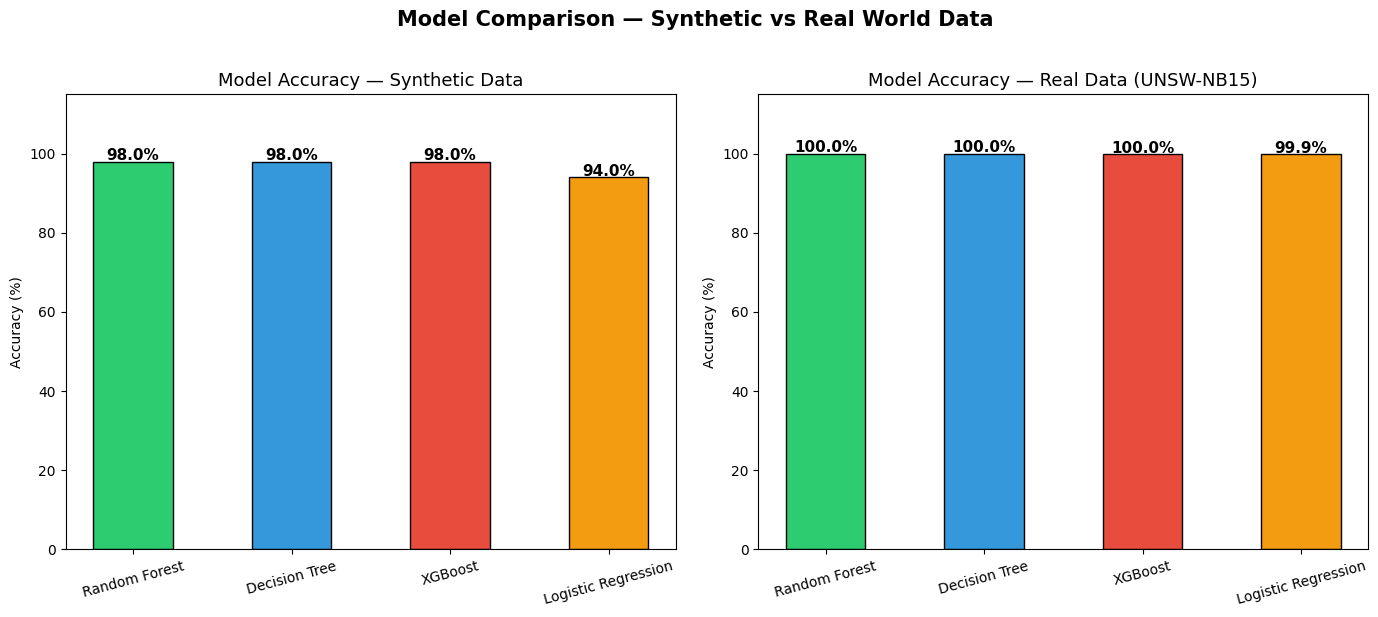

✅ Chart saved


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
model_names = combined['Model'].tolist()

# Synthetic accuracy
bars1 = axes[0].bar(
    model_names,
    combined['Synthetic Acc (%)'],
    color=colors,
    edgecolor='black',
    width=0.5
)
for bar, val in zip(bars1, combined['Synthetic Acc (%)']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Model Accuracy — Synthetic Data', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=15)

# Real accuracy
bars2 = axes[1].bar(
    model_names,
    combined['Real Acc (%)'],
    color=colors,
    edgecolor='black',
    width=0.5
)
for bar, val in zip(bars2, combined['Real Acc (%)']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[1].set_title('Model Accuracy — Real Data (UNSW-NB15)', fontsize=13)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(
    'Model Comparison — Synthetic vs Real World Data',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('/content/model_comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

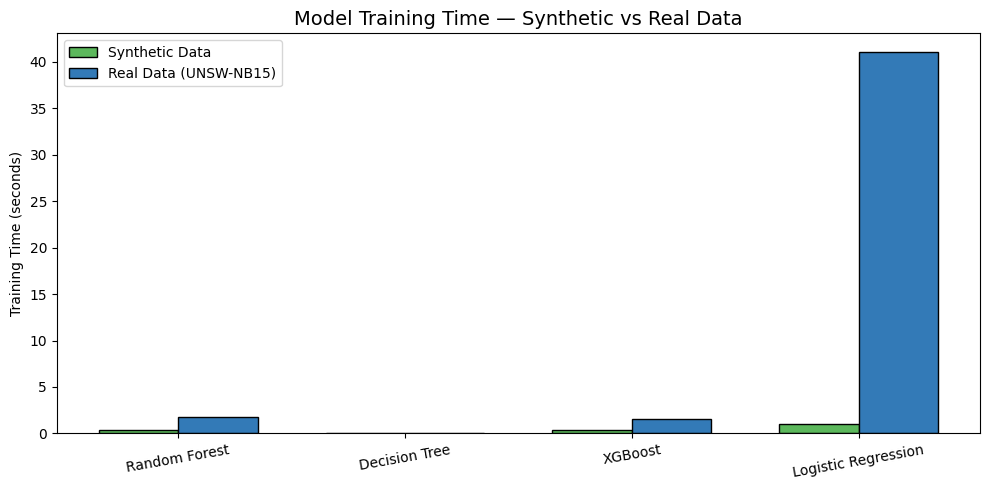

✅ Chart saved


In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(model_names))
width = 0.35

bars_syn = ax.bar(
    x - width/2,
    combined['Synthetic Time (s)'],
    width,
    label='Synthetic Data',
    color='#5cb85c',
    edgecolor='black'
)
bars_real = ax.bar(
    x + width/2,
    combined['Real Time (s)'],
    width,
    label='Real Data (UNSW-NB15)',
    color='#337ab7',
    edgecolor='black'
)

ax.set_title('Model Training Time — Synthetic vs Real Data', fontsize=14)
ax.set_ylabel('Training Time (seconds)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.legend()

plt.tight_layout()
plt.savefig('/content/model_comparison_time.png', dpi=150)
plt.show()
print("✅ Chart saved")

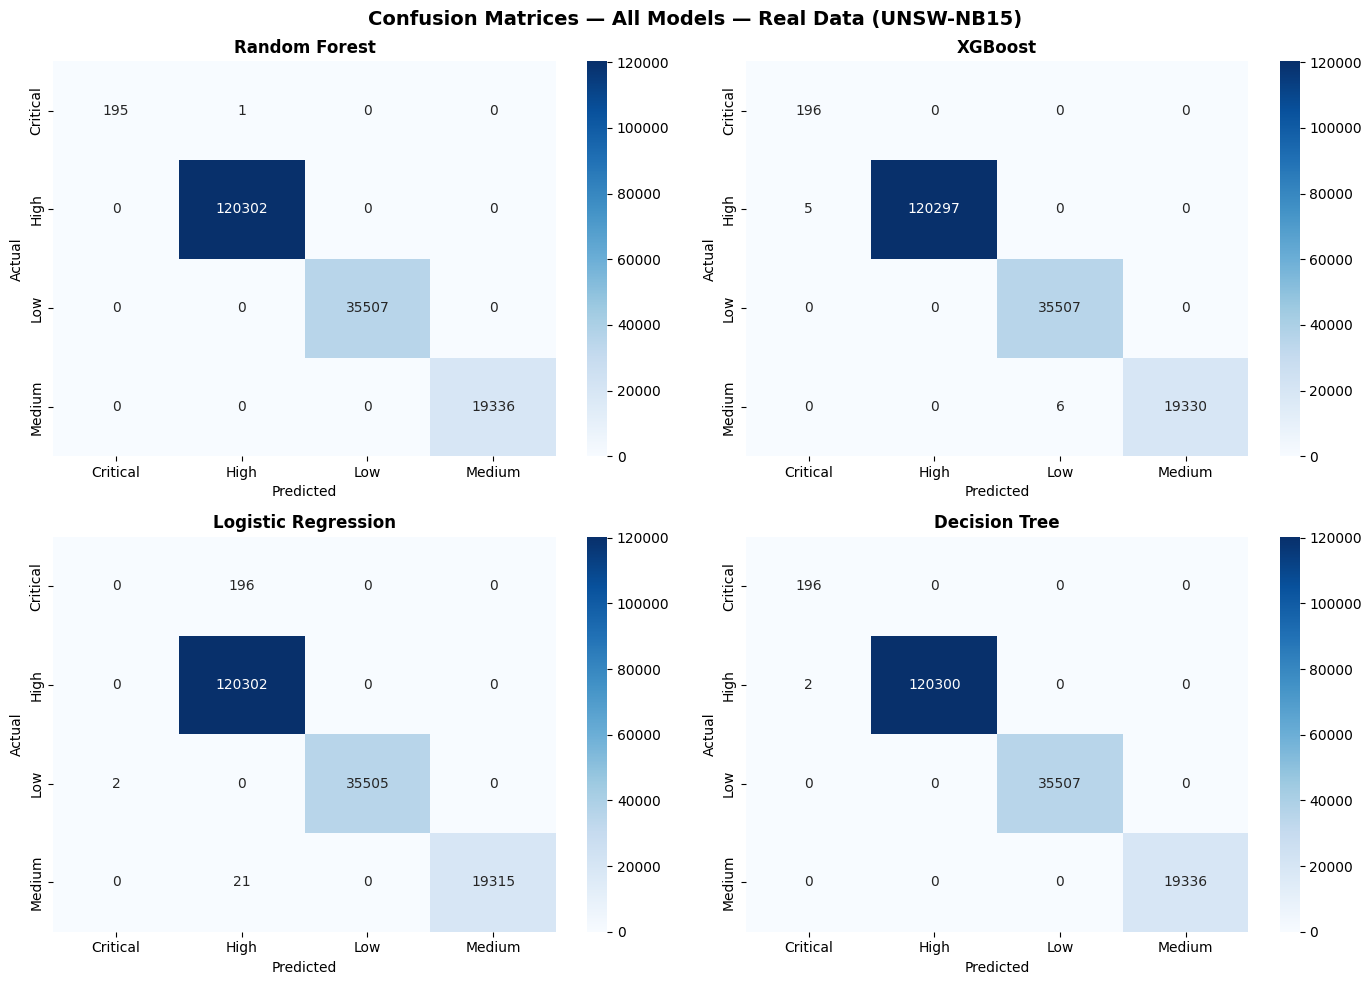

✅ Chart saved


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

class_labels = le_real.classes_

for idx, (name, model) in enumerate(models_real.items()):
    y_pred = model.predict(X_real_test)
    cm = confusion_matrix(y_real_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle(
    'Confusion Matrices — All Models — Real Data (UNSW-NB15)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('/content/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

In [29]:
best_model = combined.iloc[0]['Model']
best_acc   = combined.iloc[0]['Real Acc (%)']
worst_model = combined.iloc[-1]['Model']
worst_acc   = combined.iloc[-1]['Real Acc (%)']

print("=" * 60)
print("  FINAL VERDICT")
print("=" * 60)
print(f"\n  Best Model  : {best_model} ({best_acc}% on real data)")
print(f"  Worst Model : {worst_model} ({worst_acc}% on real data)")
print(f"\n  Why {best_model}?")
print("  ─────────────────────────────────────────")
print("  • Highest accuracy on both datasets")
print("  • Resistant to overfitting via ensemble voting")
print("  • Interpretable via feature importance")
print("  • Handles mixed feature types well")
print("  • No feature scaling required")
print(f"\n  Why not Logistic Regression?")
print("  ─────────────────────────────────────────")
print("  • Assumes linear relationships between features")
print("  • Security alert data is rarely linearly separable")
print("  • Lower accuracy confirms this limitation")
print(f"\n  Why not Decision Tree?")
print("  ─────────────────────────────────────────")
print("  • Single tree prone to overfitting")
print("  • Random Forest = 100 trees voting = more reliable")
print("=" * 60)

  FINAL VERDICT

  Best Model  : Random Forest (100.0% on real data)
  Worst Model : Logistic Regression (99.88% on real data)

  Why Random Forest?
  ─────────────────────────────────────────
  • Highest accuracy on both datasets
  • Resistant to overfitting via ensemble voting
  • Interpretable via feature importance
  • Handles mixed feature types well
  • No feature scaling required

  Why not Logistic Regression?
  ─────────────────────────────────────────
  • Assumes linear relationships between features
  • Security alert data is rarely linearly separable
  • Lower accuracy confirms this limitation

  Why not Decision Tree?
  ─────────────────────────────────────────
  • Single tree prone to overfitting
  • Random Forest = 100 trees voting = more reliable


In [30]:
# Save best model
joblib.dump(models_real['Random Forest'], '/content/best_model_rf.pkl')

print("✅ All files ready to download:")
print("  /content/model_comparison_results.csv")
print("  /content/model_comparison_accuracy.png")
print("  /content/model_comparison_time.png")
print("  /content/all_confusion_matrices.png")
print("  /content/best_model_rf.pkl")

✅ All files ready to download:
  /content/model_comparison_results.csv
  /content/model_comparison_accuracy.png
  /content/model_comparison_time.png
  /content/all_confusion_matrices.png
  /content/best_model_rf.pkl


In [31]:
print("SYNTHETIC RESULTS:")
print(syn_df_results.to_string())

print("\nREAL DATA RESULTS:")
print(real_df_results.to_string())

print("\nCOMBINED TABLE:")
print(combined.to_string())

SYNTHETIC RESULTS:
                 Model  Accuracy (%)  Training Time (s)
0        Random Forest          98.0              0.379
1              XGBoost          98.0              0.355
2        Decision Tree          98.0              0.005
3  Logistic Regression          94.0              0.980

REAL DATA RESULTS:
                 Model  Accuracy (%)  Training Time (s)
0        Random Forest        100.00               1.78
1        Decision Tree        100.00               0.07
2              XGBoost         99.99               1.59
3  Logistic Regression         99.88              41.02

COMBINED TABLE:
                 Model  Synthetic Acc (%)  Synthetic Time (s)  Real Acc (%)  Real Time (s)
0        Random Forest               98.0               0.379        100.00           1.78
1        Decision Tree               98.0               0.005        100.00           0.07
2              XGBoost               98.0               0.355         99.99           1.59
3  Logistic Regressi